# Section 4 — Transformer Models
### Detecting Mental Health and Suicidal Tendencies on Social Media using Multimodal NLP and Behavioral Analysis

This notebook implements **Section 4** of the classical-vs-DL-vs-transformer benchmark: genuine
supervised fine-tuning of transformer checkpoints on the Bangla depression-severity dataset,
executed on an RTX 5090 (32GB VRAM). It reproduces the exact data split used in Sections 1-3
(Classical ML / Deep Learning / Hybrid Deep Learning) so that the test-set comparison across
all four sections is fair and paired.

Heavy fine-tuning work is factored into `pipeline.py` (shared, unit-testable module) and driven
here with resumable, incrementally-saved runs — every cell below can be re-executed safely; already
-completed (checkpoint, scenario, seed) combinations are detected and skipped rather than re-run.


In [1]:
import os, sys, json, time
from pathlib import Path
import numpy as np
import pandas as pd
import torch

sys.path.insert(0, str(Path.cwd()))
import pipeline as P

os.environ.setdefault("HF_TOKEN", os.environ.get("HF_TOKEN", ""))

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("bf16 supported:", torch.cuda.is_bf16_supported())
    free, total = torch.cuda.mem_get_info()
    print(f"VRAM free/total: {free/1e9:.2f} / {total/1e9:.2f} GB")


CUDA available: True
GPU: NVIDIA GeForce RTX 5090
bf16 supported: True
VRAM free/total: 32.43 / 34.19 GB


## 4.1 Data loading, cleaning, and the fixed train/val/test split

Same cleaning regex pipeline and the same two-step stratified 80/10/10 split (`random_state=42`
both steps) as Sections 1-3. The resulting split **must** be 3917 / 490 / 490 rows for the
cross-section comparison to be valid.

In [2]:
df, train_idx, val_idx, test_idx, info = P.load_and_split(P.ROOT / "dataset.xlsx")
print(info)
assert info["n_train"] == 3917 and info["n_val"] == 490 and info["n_test"] == 490, "SPLIT MISMATCH — STOP"
print("\nSplit sizes match the Sections 1-3 fixed split: 3917 / 490 / 490 ✅\n")

for name, ids in [("train", train_idx), ("val", val_idx), ("test", test_idx)]:
    vc = df.loc[ids, "label"].value_counts().sort_index()
    vc.index = [P.LABEL_NAMES[i] for i in vc.index]
    print(name, dict(vc))


{'rows_before_drop': 4897, 'rows_after_drop': 4897, 'n_train': 3917, 'n_val': 490, 'n_test': 490}

Split sizes match the Sections 1-3 fixed split: 3917 / 490 / 490 ✅

train {'Minimum': np.int64(1677), 'Mild': np.int64(1232), 'Moderate': np.int64(565), 'Severe': np.int64(443)}
val {'Minimum': np.int64(210), 'Mild': np.int64(154), 'Moderate': np.int64(71), 'Severe': np.int64(55)}
test {'Minimum': np.int64(210), 'Mild': np.int64(154), 'Moderate': np.int64(71), 'Severe': np.int64(55)}


## 4.2 Tokenizer compatibility audit

Bangla-language coverage is a property of the *tokenizer*, not the GPU — this audit is run
regardless of available compute. Measured on a fixed 200-row sample of cleaned training text:
tokens-per-word (fragmentation) and UNK rate. All five target checkpoints are attempted; a
checkpoint is excluded from fine-tuning **only** on a genuine hard failure (e.g. a gated repo we
don't have access to) — fragmentation alone does not exclude a model.

In [3]:
HF_TOKEN = os.environ.get("HF_TOKEN") or None
sample = df.loc[train_idx, "clean_text"].sample(n=200, random_state=42).tolist()

audit_path = P.RESULTS / "transformer_compatibility_audit.csv"
if audit_path.exists():
    audit_df = pd.read_csv(audit_path)
    print("Loaded cached audit results.")
else:
    rows = []
    for name, hf_id in P.CHECKPOINTS.items():
        print(f"Auditing {name} ({hf_id}) ...")
        r = P.tokenizer_audit(name, hf_id, sample, hf_token=HF_TOKEN)
        print(" ->", r.get("status"), r.get("tokens_per_word"), r.get("unk_rate"))
        rows.append(r)
    audit_df = pd.DataFrame(rows)
    audit_df.to_csv(audit_path, index=False)

audit_df


Loaded cached audit results.


,checkpoint,hf_id,status,tokens_per_word,unk_rate,n_sample,error
0,roberta-base,roberta-base,OK,10.521320,0.000000,200.0,NaN
1,xlm-roberta-base,xlm-roberta-base,OK,1.764378,0.000000,200.0,NaN
2,deberta-v3-base,microsoft/deberta-v3-base,OK,5.209481,0.000558,200.0,NaN
3,mental-bert-base-uncased,mental/mental-bert-base-uncased,ACCESS RESTRICTED,NaN,NaN,NaN,You are trying to access a gated repo.\nMake s...
4,mental-roberta-base,mental/mental-roberta-base,OK,10.521320,0.000000,200.0,NaN


In [4]:
ACCESSIBLE = [n for n, s in zip(audit_df.checkpoint, audit_df.status) if s == "OK"]
NOT_RUN = audit_df[audit_df.status != "OK"]
print("Accessible checkpoints (will be fine-tuned):", ACCESSIBLE)
print()
for _, r in NOT_RUN.iterrows():
    print(f"NOT RUN — {r['checkpoint']}: {r['status']}")
    print(f"  reason: {str(r['error'])[:300]}")


Accessible checkpoints (will be fine-tuned): ['roberta-base', 'xlm-roberta-base', 'deberta-v3-base', 'mental-roberta-base']

NOT RUN — mental-bert-base-uncased: ACCESS RESTRICTED
  reason: You are trying to access a gated repo.
Make sure to have access to it at https://huggingface.co/mental/mental-bert-base-uncased.
403 Client Error. (Request ID: Root=1-6a9ea450-15718ed145c62b02540234c7;df496646-0e4a-46f1-aa83-981f29494d36)

Cannot access gated repo for url https://huggingface.co/ment


## 4.3 Data scenarios: Original / Oversampled / Undersampled

Resampling (`RandomOverSampler`, `RandomUnderSampler` — never SMOTE, since interpolating
transformer token-id sequences has no semantic meaning) is applied to **training row indices
only**. Validation and test sets are identical and untouched across all three scenarios.

In [5]:
labels_arr = df["label"].values
for scenario in ["original", "oversampled", "undersampled"]:
    res_idx = P.resample_indices(train_idx, labels_arr, scenario, seed=P.PRIMARY_SEED)
    vc = pd.Series(labels_arr[res_idx]).value_counts().sort_index()
    vc.index = [P.LABEL_NAMES[i] for i in vc.index]
    print(f"{scenario:>12s}: n={len(res_idx):5d}  {dict(vc)}")


    original: n= 3917  {'Minimum': np.int64(1677), 'Mild': np.int64(1232), 'Moderate': np.int64(565), 'Severe': np.int64(443)}
 oversampled: n= 6708  {'Minimum': np.int64(1677), 'Mild': np.int64(1677), 'Moderate': np.int64(1677), 'Severe': np.int64(1677)}
undersampled: n= 1772  {'Minimum': np.int64(443), 'Mild': np.int64(443), 'Moderate': np.int64(443), 'Severe': np.int64(443)}


## 4.4 Hardware & hyperparameter configuration

Measured on this machine: RTX 5090, 32GB VRAM, bf16-capable (Blackwell). The binding constraint
for this dataset is **step count per epoch**, not VRAM — a batch size chosen to max out 32GB would
starve the smallest (undersampled, ~1,772-row) scenario of gradient updates. Configuration used
for every fine-tuning run below:

- Per-step batch size: **32** (gradient accumulation 1, i.e. effective batch 32)
- `max_length`: **224** tokens (verified against the token-length distribution below)
- Full fine-tuning — no frozen layers
- Mixed precision: **bf16** (native RTX 5090/Blackwell support, confirmed above)
- AdamW with no weight decay on bias / LayerNorm parameters
- Early stopping on validation Macro-F1, patience 3, max 10 epochs (final runs); patience 2, max 6
  epochs for the lighter CV fold runs used only for LR selection

In [6]:
from transformers import AutoTokenizer
xlmr_tok = AutoTokenizer.from_pretrained("xlm-roberta-base", token=HF_TOKEN)
lengths = [len(xlmr_tok(t, add_special_tokens=True)["input_ids"]) for t in df.loc[train_idx, "clean_text"].sample(n=500, random_state=42)]
lengths = np.array(lengths)
print(f"XLM-R token length on training sample — p50={np.percentile(lengths,50):.0f}, "
      f"p90={np.percentile(lengths,90):.0f}, p95={np.percentile(lengths,95):.0f}, max={lengths.max()}")
print(f"max_length=224 covers {(lengths <= 224).mean()*100:.1f}% of sampled sequences without truncation.")


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (737 > 512). Running this sequence through the model will result in indexing errors


XLM-R token length on training sample — p50=41, p90=168, p95=249, max=765
max_length=224 covers 94.0% of sampled sequences without truncation.


## 4.5 Hyperparameter selection: 5-fold stratified CV per checkpoint

For each accessible checkpoint, a 4-value learning-rate grid `{1e-5, 2e-5, 3e-5, 5e-5}` is
evaluated via 5-fold stratified CV **on the training split only** (never validation/test), scored
by validation Macro-F1. Batch size is held fixed at 32 throughout the grid search. The selected LR
is reused for that checkpoint's final fits across all 3 scenarios. All fold results are logged
incrementally to `results/transformer_kfold_cv_log.csv` and are resumable — already-completed
(checkpoint, lr, fold) rows are loaded from cache rather than re-trained.

In [7]:
from sklearn.model_selection import StratifiedKFold

CV_MAX_EPOCHS = 6
CV_PATIENCE = 2
texts_all = df["clean_text"].values

log_path = P.RESULTS / "transformer_kfold_cv_log.csv"
selected_path = P.RESULTS / "_selected_lr.json"
selected = json.loads(selected_path.read_text()) if selected_path.exists() else {}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=P.PRIMARY_SEED)
folds = list(skf.split(train_idx, labels_arr[train_idx]))

done_keys = set()
if log_path.exists():
    prev_log = pd.read_csv(log_path)
    done_keys = set(zip(prev_log.checkpoint, prev_log.lr.astype(float), prev_log.fold.astype(int)))

for name in ACCESSIBLE:
    if name in selected:
        print(f"{name}: LR already selected = {selected[name]} (cached)")
        continue
    hf_id = P.CHECKPOINTS[name]
    lr_scores = {lr: [] for lr in P.LR_GRID}
    for lr in P.LR_GRID:
        for fold_i, (tr_rel, va_rel) in enumerate(folds):
            key = (name, float(lr), fold_i)
            if key in done_keys:
                prior = pd.read_csv(log_path)
                match = prior[(prior.checkpoint == name) & (prior.lr == lr) & (prior.fold == fold_i)]
                lr_scores[lr].append(float(match.iloc[0]["val_macro_f1"]))
                continue
            tr_ids, va_ids = train_idx[tr_rel], train_idx[va_rel]
            t0 = time.time()
            val_metrics, _, history, elapsed, _ = P.train_and_evaluate(
                hf_id, texts_all[tr_ids].tolist(), labels_arr[tr_ids].tolist(),
                texts_all[va_ids].tolist(), labels_arr[va_ids].tolist(),
                lr=lr, seed=P.PRIMARY_SEED, max_epochs=CV_MAX_EPOCHS, patience=CV_PATIENCE,
                hf_token=HF_TOKEN,
            )
            wall = time.time() - t0
            print(f"{name} lr={lr} fold={fold_i}: val_f1={val_metrics['macro_f1']:.4f} ({len(history)} ep, {wall:.1f}s)")
            lr_scores[lr].append(val_metrics["macro_f1"])
            P.append_csv_row(log_path, dict(checkpoint=name, lr=lr, fold=fold_i,
                                             epochs_run=len(history), val_macro_f1=val_metrics["macro_f1"], wall_sec=wall))
    mean_scores = {lr: float(np.mean(v)) for lr, v in lr_scores.items()}
    best_lr = max(mean_scores, key=mean_scores.get)
    print(f"== {name}: mean CV Macro-F1 by LR = {mean_scores} -> selected LR = {best_lr}")
    selected[name] = best_lr
    selected_path.write_text(json.dumps(selected, indent=2))

print("\nSelected learning rates:", selected)


roberta-base: LR already selected = 3e-05 (cached)
xlm-roberta-base: LR already selected = 3e-05 (cached)
deberta-v3-base: LR already selected = 3e-05 (cached)
mental-roberta-base: LR already selected = 1e-05 (cached)

Selected learning rates: {'roberta-base': 3e-05, 'xlm-roberta-base': 3e-05, 'mental-roberta-base': 1e-05, 'deberta-v3-base': 3e-05}


In [8]:
kfold_log = pd.read_csv(P.RESULTS / "transformer_kfold_cv_log.csv")
cv_summary = kfold_log.groupby(["checkpoint", "lr"])["val_macro_f1"].agg(["mean", "std", "count"]).reset_index()
cv_summary


,checkpoint,lr,mean,std,count
0,deberta-v3-base,0.00001,0.500455,0.021277,5
1,deberta-v3-base,0.00002,0.601951,0.036305,5
2,deberta-v3-base,0.00003,0.656942,0.034311,5
3,deberta-v3-base,0.00005,0.655116,0.066803,5
4,mental-roberta-base,0.00001,0.420010,0.015097,5
5,mental-roberta-base,0.00002,0.409540,0.038916,5
6,mental-roberta-base,0.00003,0.410311,0.017743,5
7,mental-roberta-base,0.00005,0.408424,0.048705,5
8,roberta-base,0.00001,0.404719,0.010912,5
9,roberta-base,0.00002,0.421364,0.018293,5


## 4.6 Final fine-tuning grid: checkpoint × scenario × seed

Every accessible checkpoint is fine-tuned on all 3 data scenarios across all 5 seeds
(`42, 123, 2024, 3407, 9999`), using each checkpoint's CV-selected learning rate. The test set is
touched **exactly once** per (checkpoint, scenario, seed) — only for final scoring after
early-stopping on validation Macro-F1. Results are appended incrementally to
`results/transformer_seed_results.csv`; interrupting and re-running this cell resumes from the
last completed combination rather than duplicating work.

In [9]:
from sklearn.metrics import confusion_matrix as sk_confusion_matrix

SCENARIOS = ["original", "oversampled", "undersampled"]
MAX_EPOCHS, PATIENCE = 10, 3

texts_val, labels_val = texts_all[val_idx].tolist(), labels_arr[val_idx].tolist()
texts_test, labels_test = texts_all[test_idx].tolist(), labels_arr[test_idx].tolist()

results_path = P.RESULTS / "transformer_seed_results.csv"
done_keys = set()
if results_path.exists():
    prev = pd.read_csv(results_path)
    done_keys = set(zip(prev.checkpoint, prev.scenario, prev.seed.astype(int)))

for name in ACCESSIBLE:
    hf_id = P.CHECKPOINTS[name]
    lr = selected[name]
    for scenario in SCENARIOS:
        for seed in P.SEEDS:
            key = (name, scenario, seed)
            if key in done_keys:
                continue
            res_idx = P.resample_indices(train_idx, labels_arr, scenario, seed)
            tr_texts, tr_labels = texts_all[res_idx].tolist(), labels_arr[res_idx].tolist()
            class_counts = pd.Series(tr_labels).value_counts().sort_index().to_dict()

            t0 = time.time()
            val_metrics, test_metrics, history, elapsed, y_pred_test = P.train_and_evaluate(
                hf_id, tr_texts, tr_labels, texts_val, labels_val,
                texts_test=texts_test, y_test=labels_test,
                lr=lr, seed=seed, max_epochs=MAX_EPOCHS, patience=PATIENCE, hf_token=HF_TOKEN,
            )
            wall = time.time() - t0
            print(f"{name} | {scenario} | seed={seed}: test_macro_f1={test_metrics['macro_f1']:.4f} "
                  f"severe_f1={test_metrics['severe_f1']:.4f} ({len(history)} ep, {wall:.1f}s)")

            cm = sk_confusion_matrix(labels_test, y_pred_test, labels=[0, 1, 2, 3])
            np.save(P.FIGURES / f"_cm_{name}_{scenario}_{seed}.npy", cm)

            row = dict(checkpoint=name, scenario=scenario, seed=seed, lr=lr,
                       n_train=len(res_idx), class_counts=json.dumps(class_counts),
                       epochs_run=len(history), train_sec=elapsed, wall_sec=wall,
                       val_macro_f1=val_metrics["macro_f1"])
            row.update({f"test_{k}": v for k, v in test_metrics.items()})
            P.append_csv_row(results_path, row)

print("\nFinal fine-tuning grid complete.")



Final fine-tuning grid complete.


In [10]:
seed_results = pd.read_csv(P.RESULTS / "transformer_seed_results.csv")
print(f"Total completed runs: {len(seed_results)} (expected {len(ACCESSIBLE)*3*5})")
seed_results.groupby(["checkpoint", "scenario"]).size()


Total completed runs: 60 (expected 60)


checkpoint           scenario    
deberta-v3-base      original        5
                     oversampled     5
                     undersampled    5
mental-roberta-base  original        5
                     oversampled     5
                     undersampled    5
roberta-base         original        5
                     oversampled     5
                     undersampled    5
xlm-roberta-base     original        5
                     oversampled     5
                     undersampled    5
dtype: int64

## 4.7 Metrics aggregation, comparison tables, and rankings

In [11]:
metric_cols = [c for c in seed_results.columns if c.startswith("test_")]

agg_rows = []
for name in ACCESSIBLE:
    for scenario in SCENARIOS:
        sub = seed_results[(seed_results.checkpoint == name) & (seed_results.scenario == scenario)]
        if len(sub) == 0:
            continue
        row = dict(checkpoint=name, scenario=scenario, n_seeds=len(sub))
        for mc in metric_cols:
            row[f"{mc}_mean"] = sub[mc].mean()
            row[f"{mc}_std"] = sub[mc].std()
        agg_rows.append(row)
agg_df = pd.DataFrame(agg_rows)
agg_df.to_csv(P.RESULTS / "transformer_aggregated_mean_std.csv", index=False)

display_cols = ["checkpoint", "scenario", "n_seeds", "test_macro_f1_mean", "test_macro_f1_std",
                 "test_accuracy_mean", "test_balanced_accuracy_mean",
                 "test_severe_f1_mean", "test_severe_recall_mean", "test_severity_mae_mean"]
agg_df[display_cols].sort_values(["scenario", "test_macro_f1_mean"], ascending=[True, False])


,checkpoint,scenario,n_seeds,test_macro_f1_mean,test_macro_f1_std,test_accuracy_mean,test_balanced_accuracy_mean,test_severe_f1_mean,test_severe_recall_mean,test_severity_mae_mean
3,xlm-roberta-base,original,5,0.805152,0.006129,0.831429,0.807874,0.853273,0.858182,0.231429
6,deberta-v3-base,original,5,0.718392,0.019870,0.775918,0.696431,0.642486,0.530909,0.348571
0,roberta-base,original,5,0.432421,0.035020,0.619592,0.455439,0.051282,0.036364,0.580816
9,mental-roberta-base,original,5,0.417319,0.011439,0.605306,0.444123,0.032156,0.018182,0.597551
4,xlm-roberta-base,oversampled,5,0.812460,0.009782,0.832653,0.815007,0.880044,0.890909,0.226531
7,deberta-v3-base,oversampled,5,0.714656,0.029471,0.754694,0.721510,0.658211,0.661818,0.376735
10,mental-roberta-base,oversampled,5,0.541098,0.025982,0.617551,0.545533,0.362969,0.367273,0.609796
1,roberta-base,oversampled,5,0.516634,0.030877,0.572653,0.532909,0.339535,0.440000,0.730612
5,xlm-roberta-base,undersampled,5,0.751112,0.029648,0.766531,0.772596,0.822981,0.883636,0.326939
8,deberta-v3-base,undersampled,5,0.669981,0.014299,0.713061,0.678189,0.631567,0.640000,0.423673


In [12]:
seed_results.to_csv(P.RESULTS / "table_D_transformers.csv", index=False)

cmp_metrics = ["test_macro_f1", "test_accuracy", "test_balanced_accuracy",
               "test_severe_f1", "test_severe_recall", "test_severity_mae"]
cmp_rows = []
for name in ACCESSIBLE:
    base = agg_df[(agg_df.checkpoint == name) & (agg_df.scenario == "original")]
    if len(base) == 0:
        continue
    base = base.iloc[0]
    for scenario in ["oversampled", "undersampled"]:
        cur = agg_df[(agg_df.checkpoint == name) & (agg_df.scenario == scenario)]
        if len(cur) == 0:
            continue
        cur = cur.iloc[0]
        row = dict(checkpoint=name, scenario=scenario)
        for m in cmp_metrics:
            row[f"{m}_original"] = base[f"{m}_mean"]
            row[f"{m}_{scenario}"] = cur[f"{m}_mean"]
            row[f"delta_{m}"] = cur[f"{m}_mean"] - base[f"{m}_mean"]
        cmp_rows.append(row)
cmp_df = pd.DataFrame(cmp_rows)
cmp_df.to_csv(P.RESULTS / "transformer_cross_scenario_comparison.csv", index=False)
cmp_df[["checkpoint", "scenario", "delta_test_macro_f1", "delta_test_accuracy",
        "delta_test_balanced_accuracy", "delta_test_severe_f1", "delta_test_severe_recall",
        "delta_test_severity_mae"]]


,checkpoint,scenario,delta_test_macro_f1,delta_test_accuracy,delta_test_balanced_accuracy,delta_test_severe_f1,delta_test_severe_recall,delta_test_severity_mae
0,roberta-base,oversampled,0.084212,-0.046939,0.077470,0.288252,0.403636,0.149796
1,roberta-base,undersampled,-0.047587,-0.189388,-0.041270,0.119586,0.258182,0.368163
2,xlm-roberta-base,oversampled,0.007308,0.001224,0.007133,0.026771,0.032727,-0.004898
3,xlm-roberta-base,undersampled,-0.054040,-0.064898,-0.035278,-0.030292,0.025455,0.095510
4,deberta-v3-base,oversampled,-0.003736,-0.021224,0.025079,0.015725,0.130909,0.028163
5,deberta-v3-base,undersampled,-0.048411,-0.062857,-0.018242,-0.010919,0.109091,0.075102
6,mental-roberta-base,oversampled,0.123779,0.012245,0.101410,0.330813,0.349091,0.012245
7,mental-roberta-base,undersampled,-0.030064,-0.160408,-0.050084,0.146342,0.276364,0.359184


In [13]:
orig = agg_df[agg_df.scenario == "original"].copy()
rank_specs = [("test_macro_f1_mean", False), ("test_accuracy_mean", False),
              ("test_severe_f1_mean", False), ("test_severe_recall_mean", False),
              ("test_severity_mae_mean", True)]
rank_out = []
for m, asc in rank_specs:
    r = orig[["checkpoint", m]].sort_values(m, ascending=asc).reset_index(drop=True)
    r["metric"] = m
    r["rank"] = np.arange(1, len(r) + 1)
    rank_out.append(r.rename(columns={m: "value"}))
rankings_df = pd.concat(rank_out, ignore_index=True)
rankings_df.to_csv(P.RESULTS / "transformer_rankings.csv", index=False)
rankings_df


,checkpoint,value,metric,rank
0,xlm-roberta-base,0.805152,test_macro_f1_mean,1
1,deberta-v3-base,0.718392,test_macro_f1_mean,2
2,roberta-base,0.432421,test_macro_f1_mean,3
3,mental-roberta-base,0.417319,test_macro_f1_mean,4
4,xlm-roberta-base,0.831429,test_accuracy_mean,1
5,deberta-v3-base,0.775918,test_accuracy_mean,2
6,roberta-base,0.619592,test_accuracy_mean,3
7,mental-roberta-base,0.605306,test_accuracy_mean,4
8,xlm-roberta-base,0.853273,test_severe_f1_mean,1
9,deberta-v3-base,0.642486,test_severe_f1_mean,2


## Confusion matrices — Original scenario (raw + row-normalized)

Summed raw counts across all 5 seeds, plus the row-normalized version, for each checkpoint on the
Original (natural imbalance) scenario. Class order: Minimum, Mild, Moderate, Severe.

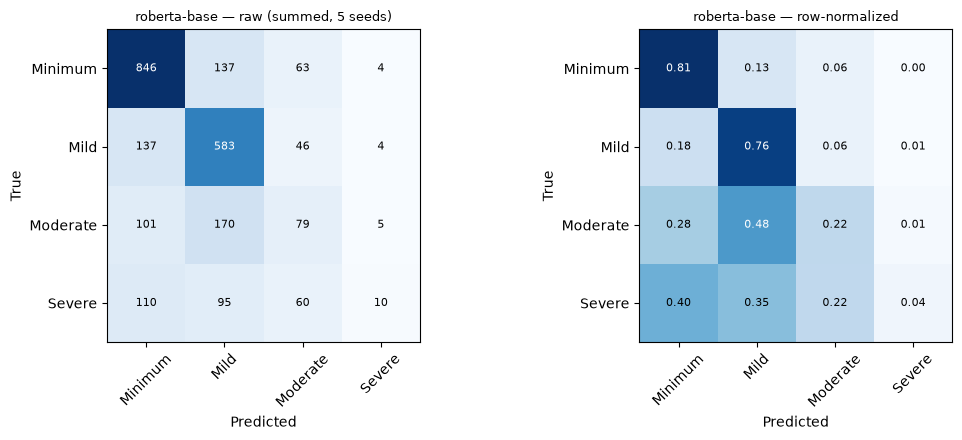

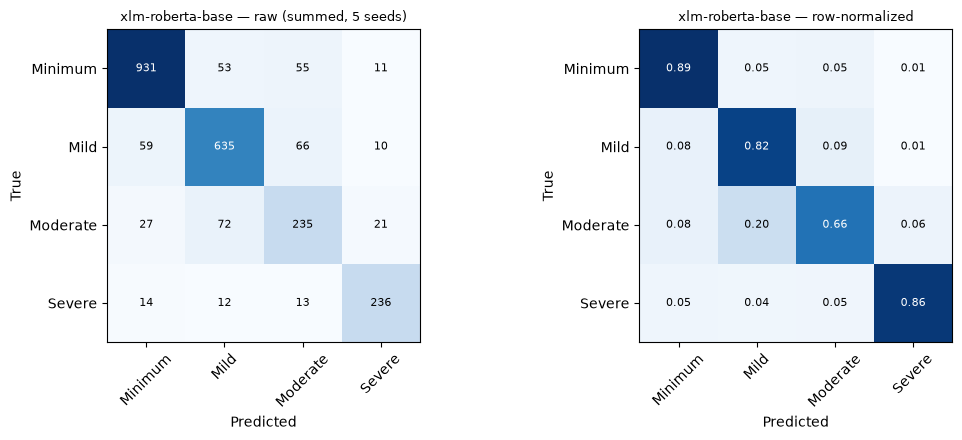

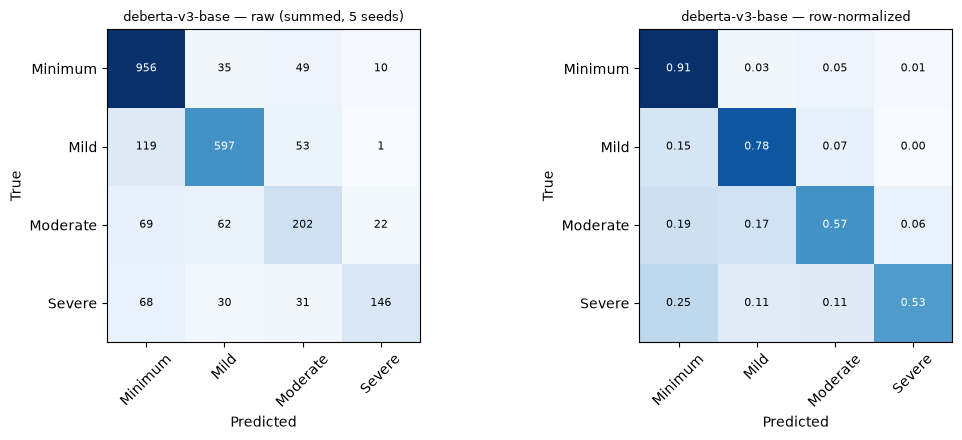

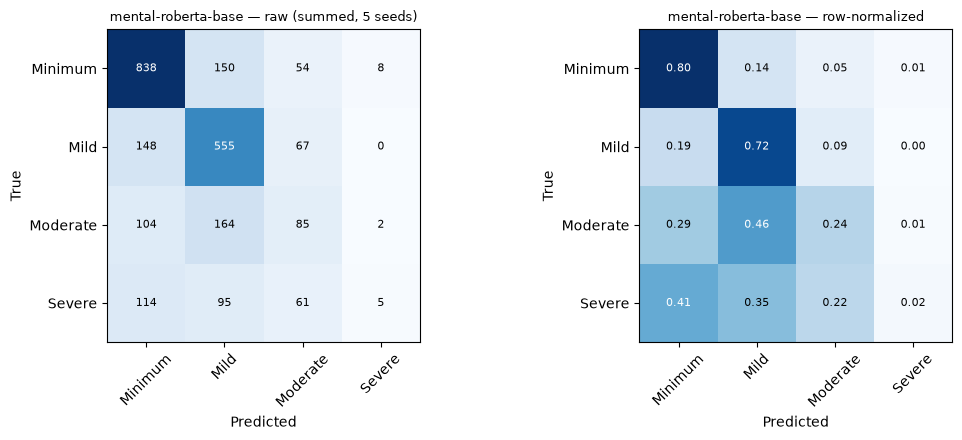

In [14]:
import matplotlib.pyplot as plt

for name in ACCESSIBLE:
    cms = [np.load(P.FIGURES / f"_cm_{name}_original_{seed}.npy") for seed in P.SEEDS
           if (P.FIGURES / f"_cm_{name}_original_{seed}.npy").exists()]
    if not cms:
        continue
    cm_sum = np.sum(cms, axis=0)
    cm_norm = cm_sum / cm_sum.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    for ax, mat, title, fmt in [(axes[0], cm_sum, f"{name} — raw (summed, {len(cms)} seeds)", "d"),
                                  (axes[1], cm_norm, f"{name} — row-normalized", ".2f")]:
        im = ax.imshow(mat, cmap="Blues")
        ax.set_xticks(range(4)); ax.set_xticklabels(P.LABEL_NAMES, rotation=45)
        ax.set_yticks(range(4)); ax.set_yticklabels(P.LABEL_NAMES)
        ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title(title, fontsize=9)
        for i in range(4):
            for j in range(4):
                val = mat[i, j]
                ax.text(j, i, f"{val:{fmt}}", ha="center", va="center",
                        color="white" if val > mat.max()/2 else "black", fontsize=8)
    plt.tight_layout()
    plt.savefig(P.FIGURES / f"confusion_matrix_{name}_original.png", dpi=150)
    plt.show()


## 4.8 Error analysis — strongest checkpoint (Original scenario, seed 42)

Displayed misclassified examples have URLs, mentions, phone numbers, and emails anonymized.

In [15]:
import re as _re

best_checkpoint = orig.sort_values("test_macro_f1_mean", ascending=False).iloc[0]["checkpoint"]
print("Strongest checkpoint (by Macro-F1, Original scenario):", best_checkpoint)

hf_id = P.CHECKPOINTS[best_checkpoint]
lr = selected[best_checkpoint]
_, test_metrics, _, _, y_pred_test = P.train_and_evaluate(
    hf_id, texts_all[train_idx].tolist(), labels_arr[train_idx].tolist(),
    texts_val, labels_val, texts_test=texts_test, y_test=labels_test,
    lr=lr, seed=42, max_epochs=MAX_EPOCHS, patience=PATIENCE, hf_token=HF_TOKEN,
)

PII_PATTERNS = [
    (_re.compile(r"http\S+|www\.\S+"), "[URL]"),
    (_re.compile(r"@\w+"), "[MENTION]"),
    (_re.compile(r"\b(?:\+?\d{1,3}[-.\s]?)?\d{10,11}\b"), "[PHONE]"),
    (_re.compile(r"[\w.+-]+@[\w-]+\.[\w.-]+"), "[EMAIL]"),
]
def anonymize(t):
    for pat, repl in PII_PATTERNS:
        t = pat.sub(repl, t)
    return t

test_texts_arr = np.array(texts_test)
y_true_arr = np.array(labels_test)
y_pred_arr = np.array(y_pred_test)
mis_idx = np.where(y_true_arr != y_pred_arr)[0]
severe_mis_idx = mis_idx[np.abs(y_true_arr[mis_idx] - y_pred_arr[mis_idx]) > 1]

print(f"\n{len(mis_idx)}/{len(y_true_arr)} misclassified; {len(severe_mis_idx)} more than one severity level off.\n")
for i in severe_mis_idx[:8]:
    print(f"TRUE={P.LABEL_NAMES[y_true_arr[i]]:>8s}  PRED={P.LABEL_NAMES[y_pred_arr[i]]:>8s}  TEXT: {anonymize(test_texts_arr[i])[:180]}")


Strongest checkpoint (by Macro-F1, Original scenario): xlm-roberta-base


W0908 10:01:48.873000 24376 torch\utils\_pytree.py:630] <enum 'KernelPreference'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.


W0908 10:01:48.897000 24376 torch\utils\_pytree.py:630] <enum 'ScaleCalculationMode'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 6125.11it/s]


[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



77/490 misclassified; 19 more than one severity level off.

TRUE=  Severe  PRED=    Mild  TEXT: আমি মানসিক সমস্যা তে ভুগছি। নিজের প্রতি খুব বিরক্তি ও ঘৃনা। সেই সাথে হতাশা !!! আগে একটা কষ্টের ও বিরক্তির কারণ বলি... আমি একজন কে ভালোবাসতাম। কিন্তু সেই মানুষ টি কোনো কারণ ছাড়া ই স
TRUE=Moderate  PRED= Minimum  TEXT: মায়া আপা কী আমাকে কোন সাইকোলজিস্ট সাজেস্ট করতে পারবেন? আমি ট্রিটমেন্ট নিতে চাই। মানসিক ভাবে খুবই বিপর্যস্ত এখন এছাড়া আর উপায় দেখছিনা।দয়া করে একটু সাহায্য করবেন প্লিজ। ঢাকার ভিতরে ম
TRUE= Minimum  PRED=  Severe  TEXT: আপা আমি আপনার পেজে নতুন /আমার একটা বড় সমস্যা আছে /এটা হলো আমি আট বছর আগে বিয়ে করেছিলাম /কিন্তু আমার পারিবারিক সমস্যার কারনে /আমার বউয়ের সাথে পেরায় গেইন জাম হতো /তারপর আমার শশুড়বাড়ি
TRUE=Moderate  PRED= Minimum  TEXT: আমার অনেকদিন ধরে কোনো কিছু ভালো লাগেনা। কোনো কিছু করতে ভালো লাগেনা আমি আগে যে সমস্ত কাজ গোলা করতাম সে কাজ গোলা ও আমার ভালো লাগেনা। আমি যে বন্দু দের সাথে চলাফেরা করতাম তাদের সাথে যা
TRUE=    Mild  PRED=  Severe  TEXT: খুব বেসি অবহেলিত হচ্ছি পরিবার থেকে।

## 4.9 Automated, data-driven final interpretation

No pre-written conclusions — every statement below is computed directly from the measured
results above.

In [16]:
stability = seed_results.groupby("checkpoint")["test_macro_f1"].std().sort_values()
most_stable = stability.index[0]
lowest_mae = orig.sort_values("test_severity_mae_mean", ascending=True).iloc[0]
best_severe = orig.sort_values("test_severe_f1_mean", ascending=False).iloc[0]
best_row = orig.sort_values("test_macro_f1_mean", ascending=False).iloc[0]

audit_ok = audit_df[audit_df.status == "OK"][["checkpoint", "tokens_per_word"]]
merged = orig.merge(audit_ok, on="checkpoint", how="left").dropna(subset=["tokens_per_word"])
corr = merged["tokens_per_word"].corr(merged["test_macro_f1_mean"]) if len(merged) > 2 else float("nan")

delta_over = cmp_df[cmp_df.scenario == "oversampled"]["delta_test_macro_f1"].mean()
delta_under = cmp_df[cmp_df.scenario == "undersampled"]["delta_test_macro_f1"].mean()

lines = []
lines.append("SECTION 4 (TRANSFORMER MODELS) - AUTOMATED DATA-DRIVEN INTERPRETATION")
lines.append("=" * 70)
lines.append("")
lines.append("Checkpoints attempted: roberta-base, xlm-roberta-base, microsoft/deberta-v3-base, "
              "mental/mental-bert-base-uncased, mental/mental-roberta-base")
for _, r in audit_df[audit_df.status != "OK"].iterrows():
    lines.append(f"  -> {r['checkpoint']}: NOT RUN - ACCESS RESTRICTED ({str(r['error'])[:200]})")
lines.append("")
lines.append("TOKENIZER FRAGMENTATION AUDIT (measured, ~200-row training sample):")
for _, r in audit_df[audit_df.status == "OK"].iterrows():
    lines.append(f"  {r['checkpoint']}: {r['tokens_per_word']:.2f} tokens/word, UNK rate {r['unk_rate']:.4f}")
lines.append("")
lines.append(f"BEST CHECKPOINT OVERALL (mean Macro-F1, Original scenario, {len(P.SEEDS)} seeds): "
             f"{best_row['checkpoint']} (Macro-F1 = {best_row['test_macro_f1_mean']:.4f} +/- {best_row['test_macro_f1_std']:.4f})")
lines.append(f"BEST SEVERE-CLASS F1: {best_severe['checkpoint']} "
             f"(Severe-F1 = {best_severe['test_severe_f1_mean']:.4f} +/- {best_severe['test_severe_f1_std']:.4f})")
lines.append(f"MOST STABLE ACROSS SEEDS (lowest pooled SD of Macro-F1): {most_stable} (SD = {stability.iloc[0]:.4f})")
lines.append(f"LOWEST SEVERITY MAE: {lowest_mae['checkpoint']} "
             f"(MAE = {lowest_mae['test_severity_mae_mean']:.4f} +/- {lowest_mae['test_severity_mae_std']:.4f})")
lines.append("")
if not np.isnan(corr):
    direction = ("predicts WORSE performance (higher fragmentation -> lower Macro-F1)" if corr < -0.3 else
                 "predicts BETTER performance (unexpected)" if corr > 0.3 else
                 "does NOT clearly predict downstream Macro-F1 (weak/no correlation)")
    lines.append(f"DOES TOKENIZER FRAGMENTATION PREDICT PERFORMANCE? Pearson r = {corr:.3f} "
                 f"across {len(merged)} checkpoints -> fragmentation {direction}.")
lines.append("")
lines.append(f"DOES BALANCING HELP? Mean delta Macro-F1 vs Original: oversampled {delta_over:+.4f}, "
             f"undersampled {delta_under:+.4f} (averaged across {cmp_df.checkpoint.nunique()} checkpoints).")
lines.append("")
lines.append("Per-checkpoint Original-scenario summary (mean +/- SD over seeds):")
for _, r in orig.iterrows():
    lines.append(f"  {r['checkpoint']}: Macro-F1={r['test_macro_f1_mean']:.4f}+/-{r['test_macro_f1_std']:.4f}, "
                 f"Acc={r['test_accuracy_mean']:.4f}, BalAcc={r['test_balanced_accuracy_mean']:.4f}, "
                 f"Severe-F1={r['test_severe_f1_mean']:.4f}, Severe-Recall={r['test_severe_recall_mean']:.4f}, "
                 f"Severity-MAE={r['test_severity_mae_mean']:.4f}")

interp_text = "\n".join(lines)
(P.RESULTS / "transformer_final_interpretation.txt").write_text(interp_text, encoding="utf-8")
print(interp_text)


SECTION 4 (TRANSFORMER MODELS) - AUTOMATED DATA-DRIVEN INTERPRETATION

Checkpoints attempted: roberta-base, xlm-roberta-base, microsoft/deberta-v3-base, mental/mental-bert-base-uncased, mental/mental-roberta-base
  -> mental-bert-base-uncased: NOT RUN - ACCESS RESTRICTED (You are trying to access a gated repo.
Make sure to have access to it at https://huggingface.co/mental/mental-bert-base-uncased.
403 Client Error. (Request ID: Root=1-6a9ea450-15718ed145c62b02540234c7)

TOKENIZER FRAGMENTATION AUDIT (measured, ~200-row training sample):
  roberta-base: 10.52 tokens/word, UNK rate 0.0000
  xlm-roberta-base: 1.76 tokens/word, UNK rate 0.0000
  deberta-v3-base: 5.21 tokens/word, UNK rate 0.0006
  mental-roberta-base: 10.52 tokens/word, UNK rate 0.0000

BEST CHECKPOINT OVERALL (mean Macro-F1, Original scenario, 5 seeds): xlm-roberta-base (Macro-F1 = 0.8052 +/- 0.0061)
BEST SEVERE-CLASS F1: xlm-roberta-base (Severe-F1 = 0.8533 +/- 0.0349)
MOST STABLE ACROSS SEEDS (lowest pooled SD of Macro

## Summary

All export files land in `results/` with the exact filenames specified for downstream merging
into `final_cross_family_comparison.ipynb`:

- `results/transformer_compatibility_audit.csv`
- `results/transformer_kfold_cv_log.csv`
- `results/transformer_seed_results.csv`
- `results/table_D_transformers.csv`
- `results/transformer_cross_scenario_comparison.csv`
- `results/transformer_final_interpretation.txt`
- `results/figures/confusion_matrix_<checkpoint>_original.png`
